In [2]:
# =========================
# STEP 0 — IMPORTS, PATH, FOLDERS
# =========================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# For display in Jupyter (nice tables)
try:
    from IPython.display import display
except ImportError:
    def display(x): print(x.head() if hasattr(x, "head") else x)

# >>> Path to your dataset
DATA_PATH = r"C:\Users\dusik\OneDrive\Desktop\Y2S1\Data\raw\diabetic_data.csv"

# >>> Absolute folders for saving results
MISSING_DIR = r"C:\Users\dusik\OneDrive\Desktop\Y2S1\Results\MissingData"
OUTPUTS_DIR = r"C:\Users\dusik\OneDrive\Desktop\Y2S1\Results\Outputs"

# Create folders if they don’t exist
os.makedirs(MISSING_DIR, exist_ok=True)
os.makedirs(OUTPUTS_DIR, exist_ok=True)

# Pandas display options
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

print("Missing data visualizations will be saved to:", MISSING_DIR)
print("Outputs will be saved to:", OUTPUTS_DIR)

Missing data visualizations will be saved to: C:\Users\dusik\OneDrive\Desktop\Y2S1\Results\MissingData
Outputs will be saved to: C:\Users\dusik\OneDrive\Desktop\Y2S1\Results\Outputs


In [3]:
# =========================
# STEP 1 — LOAD DATASET
# =========================
df_raw = pd.read_csv(DATA_PATH)
print("Raw shape:", df_raw.shape)
display(df_raw.head())

Raw shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [4]:
# =========================
# STEP 2 — STANDARDIZE PLACEHOLDER MISSING VALUES
# =========================
PLACEHOLDERS = ["?", "Unknown/Invalid", "Unknown", "None", "N/A", "NA", "NULL", "Not Available"]

df = df_raw.replace(PLACEHOLDERS, np.nan)

print("Missing values after standardization:", df.isna().sum().sum())

Missing values after standardization: 374020


Top missing columns:


weight                 98569
max_glu_serum          96420
A1Cresult              84748
medical_specialty      49949
payer_code             40256
race                    2273
diag_3                  1423
diag_2                   358
diag_1                    21
gender                     3
time_in_hospital           0
admission_source_id        0
num_lab_procedures         0
encounter_id               0
patient_nbr                0
dtype: int64


Columns with more than 60% missing:


weight           96.858479
max_glu_serum    94.746772
A1Cresult        83.277322
dtype: float64

Saved missing data report to: C:\Users\dusik\OneDrive\Desktop\Y2S1\Results\Outputs\missing_data_report.csv


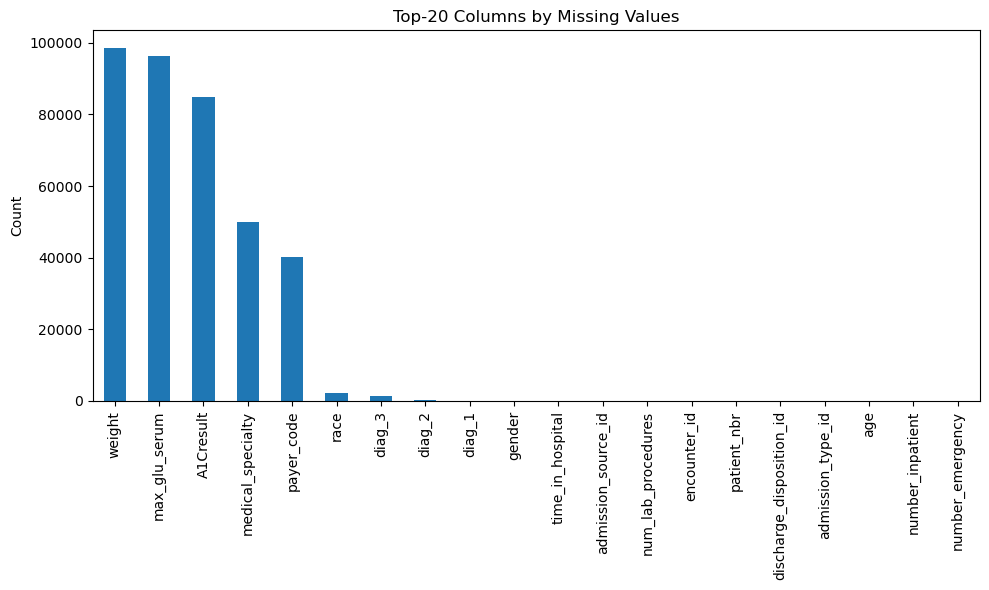

In [5]:
# =========================
# STEP 3 — AUDIT MISSING VALUES
# =========================
missing_counts = df.isna().sum().sort_values(ascending=False)
missing_ratio  = (df.isna().mean() * 100).sort_values(ascending=False)

print("Top missing columns:")
display(missing_counts.head(15))

print("\nColumns with more than 60% missing:")
display(missing_ratio[missing_ratio > 60])

# Save audit report
audit_report = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_percent": missing_ratio
})
audit_path = os.path.join(OUTPUTS_DIR, "missing_data_report.csv")
audit_report.to_csv(audit_path)
print("Saved missing data report to:", audit_path)

# Plot top-20 missing columns
plt.figure(figsize=(10,6))
missing_counts.head(20).plot(kind="bar")
plt.title("Top-20 Columns by Missing Values")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(os.path.join(MISSING_DIR, "missing_top20.png"), dpi=150)
plt.show()

In [6]:
# =========================
# STEP 4 — DROP HIGH-NA COLUMNS
# =========================
HIGH_NA_THRESHOLD = 0.90
drop_cols = [c for c in df.columns if df[c].isna().mean() > HIGH_NA_THRESHOLD]

# Example: keep medically important signals if required
for keep_col in ["max_glu_serum", "A1Cresult"]:
    if keep_col in drop_cols:
        drop_cols.remove(keep_col)

print("Dropping columns:", drop_cols)

df = df.drop(columns=drop_cols)
print("Shape after drops:", df.shape)

Dropping columns: ['weight']
Shape after drops: (101766, 49)


In [7]:
# =========================
# STEP 5 — IMPUTE REMAINING MISSING VALUES
# =========================
num_cols = df.select_dtypes(include=[np.number]).columns
cat_cols = df.select_dtypes(include=["object"]).columns

# Numeric → median
for col in num_cols:
    if df[col].isna().any():
        df[col] = df[col].fillna(df[col].median())

# Categorical → mode (or 'Unknown' if empty)
for col in cat_cols:
    if df[col].isna().any():
        mode = df[col].mode(dropna=True)
        df[col] = df[col].fillna(mode.iloc[0] if not mode.empty else "Unknown")

print("Remaining total missing values:", df.isna().sum().sum())

Remaining total missing values: 0


In [8]:
# =========================
# STEP 6 — SAVE CLEANED DATASET
# =========================
cleaned_path = os.path.join(OUTPUTS_DIR, "diabetic_missing_handled.csv")
df.to_csv(cleaned_path, index=False)
print("Saved cleaned dataset to:", cleaned_path)


Saved cleaned dataset to: C:\Users\dusik\OneDrive\Desktop\Y2S1\Results\Outputs\diabetic_missing_handled.csv
